In [1]:
import torch
import torchphysics as tp
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import os
from pytorch_lightning import loggers as pl_loggers
# GAN macros
GPU="cpu"
GAN_weight=1 # Generator weight
L_x=3.6 # length of domain
N_x=200 # grid in x
N_x_sub=64
N_y=100 # grid in y
N_dists=1 # N 1d roughness for fake images during trainingN_epochs
N_epochs=2000 # N training iteration each epoch
GP_weight=10
Grid_data=True



/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
C = tp.spaces.R1("c") # number of case
#output
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
UV=tp.spaces.R1('uv')
P=tp.spaces.R1('p')

In [3]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [4]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature_CNN(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=15):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_r=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_r=nn.Linear(in_features=150,out_features=150,device=GPU)


        self.conv1=nn.Conv1d(1,5,3,stride=1,padding=1,device=GPU) #((720-3+2*1)/1)+1 *8=720 *5
        self.act1=nn.LeakyReLU(0.1)
        #self.pool1=nn.MaxPool1d(kernel_size=2) # stride=2   (720-2)/2 + 1 *8 = 360 *3
        
        self.conv2=nn.Conv1d(5,9,3,stride=1,padding=1,device=GPU) # ((720-3+2*1)/1)+1 *32 = 720*9
        self.act2=nn.LeakyReLU(0.1)
        #self.pool2=nn.MaxPool1d(kernel_size=2) #360*6

        self.conv3=nn.Conv1d(9,15,5,stride=3,padding=1,device=GPU) #((720-5+2*1)/3)+1 *32 = 240*15
        self.act3=nn.LeakyReLU(0.1)
        self.pool3=nn.MaxPool1d(kernel_size=2)# 120*9
        self.conv4=nn.Conv1d(15,20,5,stride=3,padding=1,device=GPU) #((120-5+2*1)/3)+1 *32 = 40*20
        self.act4=nn.LeakyReLU(0.1)
        self.pool4=nn.MaxPool1d(kernel_size=2)# 20*20

        self.flat=nn.Flatten()
        
        self.fc_combo1=nn.Linear(in_features=400+300,out_features=512,device=GPU)
        self.fc_combo2=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo3=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo4=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo5=nn.Linear(in_features=512,out_features=512,device=GPU)
        self.fc_combo6=nn.Linear(in_features=512,out_features=256,device=GPU)


        
        self.out=nn.Linear(in_features=256,out_features=output_space.dim,device=GPU)
    def forward(self,dist_1d,t):
        t=t.as_tensor[:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=self_sin(self.fc1_l(t_1))
        t_1=self_sin(self.fc2_l(t_1))
        t_1=self_sin(self.fc3_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=self_sin(self.fc1_r(t_2))
        t_2=self_sin(self.fc2_r(t_2))
        t_2=self_sin(self.fc3_r(t_2))
        t_figure=self.act1(self.conv1(dist_1d))
        t_figure=self.act2(self.conv2(t_figure))
        t_figure=self.pool3(self.act3(self.conv3(t_figure)))
        t_figure=self.pool4(self.act4(self.conv4(t_figure)))
        t=torch.concat((t_1,t_2,self.flat(t_figure)),1)
        t=self_sin(self.fc_combo1(t))
        t=self_sin(self.fc_combo2(t))
        t=self_sin(self.fc_combo3(t))
        t=self_sin(self.fc_combo4(t))
        t=self_sin(self.fc_combo5(t))
        t=self_sin(self.fc_combo6(t))
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature_CNN(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)


/tmp/ipykernel_912985/2793761603.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_912985/2793761603.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_2, dtype=torch.float32, requires_grad=False)


In [5]:
model=torch.load("Homemodel.pt",map_location=torch.device('cpu'))

In [6]:
DF_DIST=pd.read_csv("../Data/dist_2289_1Ds.csv",header=None)
x_corr=DF_DIST.iloc[0].to_numpy()
dist=DF_DIST.iloc[1:].to_numpy()
x_corr_new=np.linspace(min(x_corr),max(x_corr),N_x)
dist_new=np.zeros((len(dist),N_x))
for i in range(len(dist)):
    dist_new[i,:]=np.interp(x_corr_new,x_corr,dist[i])
x_corr_new=torch.tensor(x_corr_new,requires_grad=False, dtype=torch.float32,device=GPU)
x_corr=torch.tensor(x_corr,requires_grad=False, dtype=torch.float32,device=GPU)
dist_new=torch.tensor(dist_new,requires_grad=False, dtype=torch.float32,device=GPU)
dist=torch.tensor(dist, requires_grad=False,dtype=torch.float32,device=GPU)

In [7]:
def produce_sample(x_max,y_max,c,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,200)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_uv=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    dist_1d=dist[c][None,None,:]
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j],c]], dtype=torch.float32,device=GPU)
            model_value_x[j,i] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,0]
            model_value_y[j,i] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,1]
            model_value_urms[j,i] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,2]
            model_value_uv[j,i] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,4]
            model_value_p[j,i] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_uv=np.transpose(model_value_uv)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    #plt.contourf(np.linspace(0,3.6,200),np.linspace(0,1,resolution),model_value_urms,levels=10,origin='lower')    
    #plt.colorbar()
    #plt.plot(x_corr.cpu(),dist[c].cpu())
    return model_value_x, model_value_y, model_value_urms, model_value_uv, model_value_p

In [8]:
dist_c=5
model_values=produce_sample(3.6,1,dist_c,100)


(0.0, 3.6)

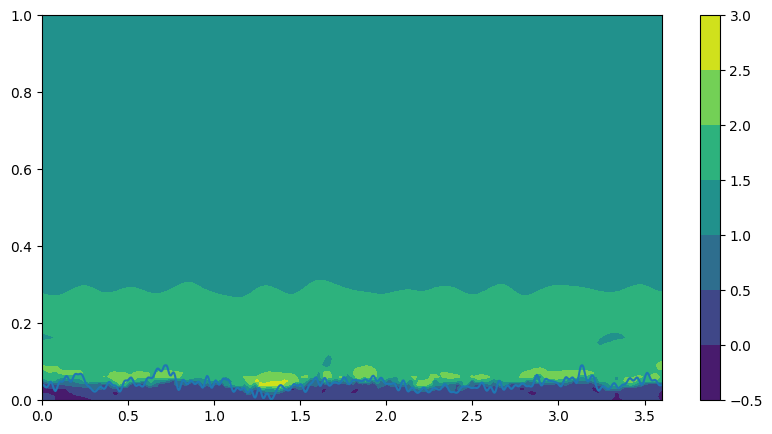

In [9]:
model_values[0].shape
plt.figure(figsize=(10,5))
levels = np.linspace(-2.2, 2.2, 11)
plt.contourf(np.linspace(0,3.6,200),np.linspace(0,1,100),model_values[2].T,levels=5,extent=[0, 3.6, 0, 1],origin='lower')
plt.colorbar()
plt.plot(x_corr.cpu(),dist[dist_c].cpu())
plt.xlim(0,3.6)

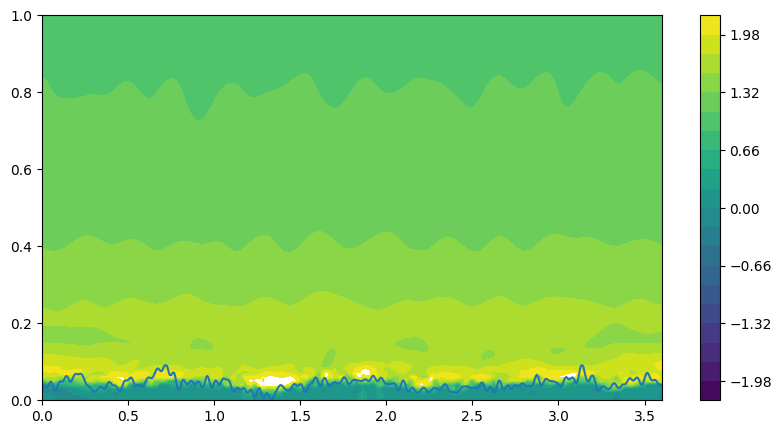

In [10]:
model_values[0].shape
plt.figure(figsize=(10,5))
levels = np.linspace(-2.2, 2.2, 21)
plt.contourf(np.linspace(0,3.6,200),np.linspace(0,1,100),model_values[2].T,levels=levels,extent=[0, 3.6, 0, 1],origin='lower')
plt.colorbar()
plt.plot(x_corr.cpu(),dist[dist_c].cpu())
plt.xlim(0,3.6)
plt.savefig("predictedurms_2D.png")

In [11]:
DF_Data=pd.read_csv("../Data/Flow_3d_mesh_2289_6_X200Y100_half.csv")
N_c=len(DF_Data["c"].unique()) # number of available training data
Data_Pinn=torch.permute(torch.tensor(DF_Data[["U","V","urms","vrms","uv"]].to_numpy(),dtype=torch.float32,device=GPU).reshape((N_c,N_x,N_y,5)),(0,3,1,2))


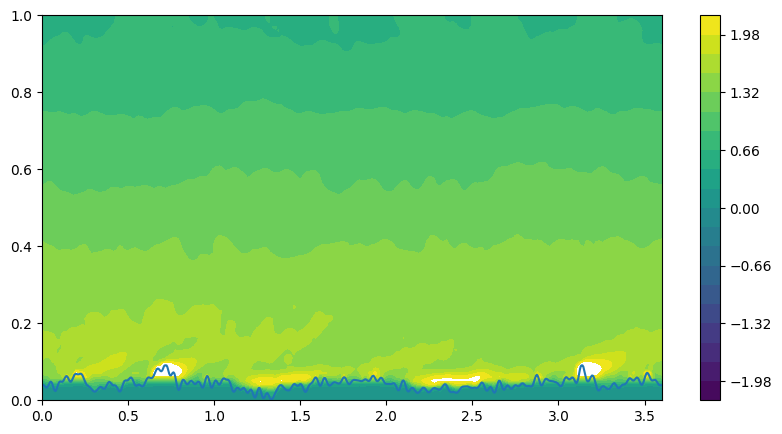

In [12]:
plt.figure(figsize=(10,5))
levels = np.linspace(-2.2, 2.2, 21)
plt.contourf(np.linspace(0,3.6,200),np.linspace(0,1,100),Data_Pinn[dist_c,2,:,:].T,levels=levels,extent=[0, 3.6, 0, 1],origin='lower')
plt.colorbar()
plt.plot(x_corr.cpu(),dist[dist_c].cpu())
plt.xlim(0,3.6)
plt.savefig("truthurms_2D.png")

/tmp/ipykernel_912985/3648853411.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  residual=abs(torch.tensor(model_values)[component].T-Data_Pinn[dist_c,component,:,:].T)/abs(Data_Pinn[dist_c,component,:,:].T)


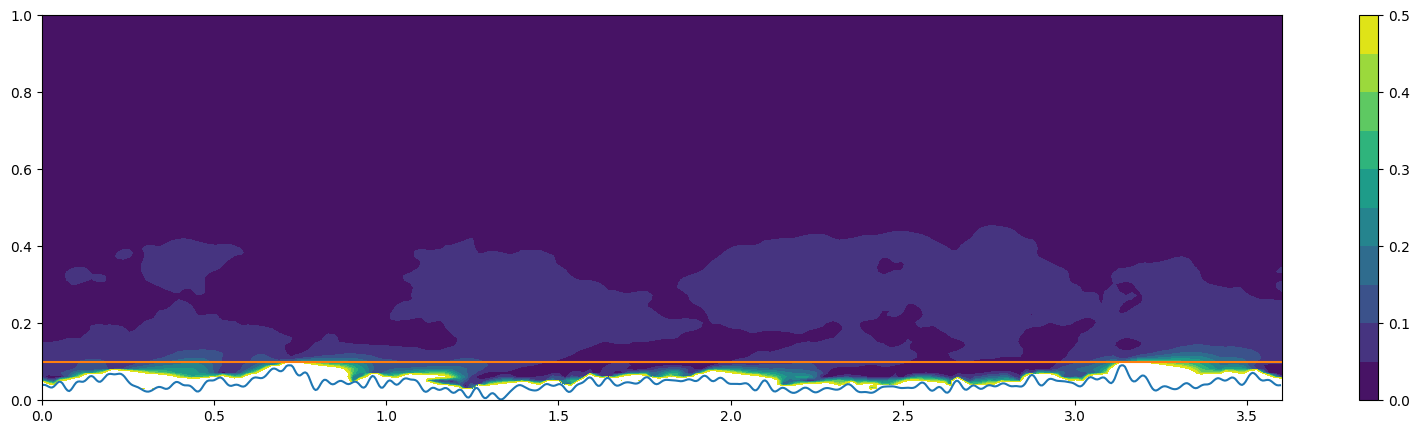

In [13]:
component=0
residual=abs(torch.tensor(model_values)[component].T-Data_Pinn[dist_c,component,:,:].T)/abs(Data_Pinn[dist_c,component,:,:].T)
levels_err = np.linspace(0, 0.5, 11)
plt.figure(figsize=(20,5))
plt.contourf(np.linspace(0,3.6,200),np.linspace(0,1,100),residual,levels=levels_err,origin="lower")
plt.colorbar()
plt.plot(x_corr.cpu(),dist[dist_c].cpu())
plt.plot([0,3.6],[0.10,0.10])

In [14]:
residual.shape

torch.Size([100, 200])

In [15]:
meanerr=residual[10:,:].mean()
meanerr

tensor(0.0293, dtype=torch.float64)

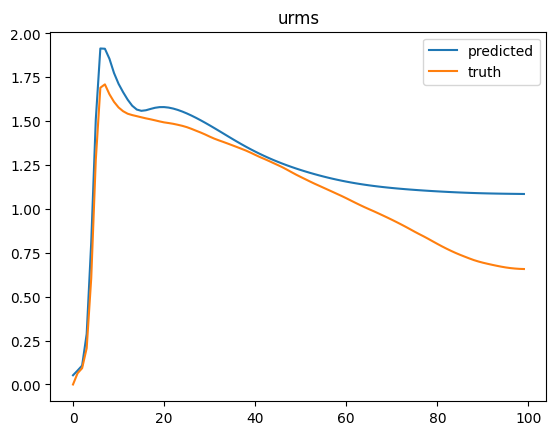

In [16]:
Uprofile=np.mean(model_values[2],axis=0)
Uprofile_real=torch.mean(Data_Pinn[0,2,:,:],dim=0)
plt.plot(Uprofile,label="predicted")
plt.plot(Uprofile_real,label="truth")
plt.legend()
plt.title("urms")
#plt.xscale("log")
plt.savefig("compare_urms.png")

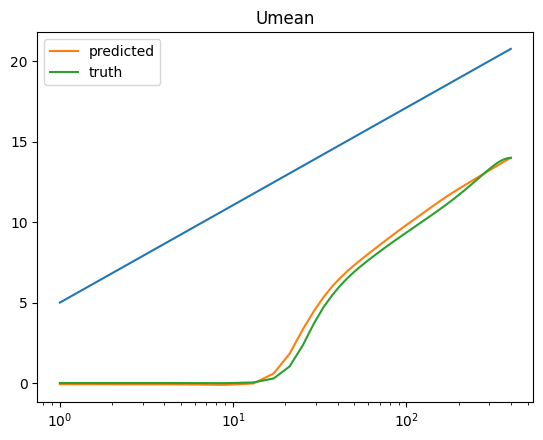

In [17]:
Uprofile=np.mean(model_values[0],axis=0)
Uprofile_real=torch.mean(Data_Pinn[0,0,:,:],dim=0)
x=torch.linspace(1,400,10)
y=1/0.38*torch.log(x)+5
plt.plot(x,y)
plt.plot(torch.linspace(1,400,100),Uprofile/0.1402,label="predicted")
plt.plot(torch.linspace(1,400,100),Uprofile_real/0.1402,label="truth")
plt.legend()
plt.xscale("log")
plt.title("Umean")
plt.savefig("compare_U.png")

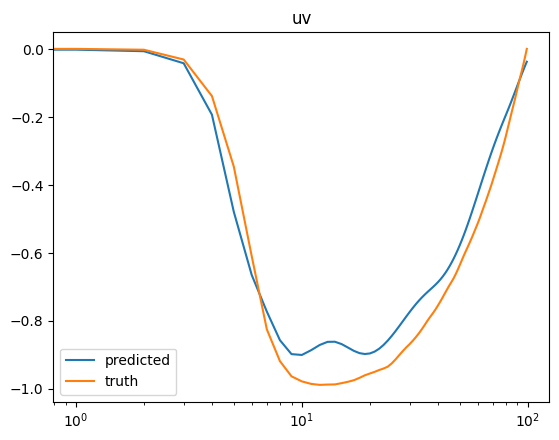

In [18]:
Uprofile=np.mean(model_values[3],axis=0)
Uprofile_real=torch.mean(Data_Pinn[0,4,:,:],dim=0)
plt.plot(Uprofile,label="predicted")
plt.plot(Uprofile_real,label="truth")
plt.legend()
plt.title("uv")
plt.xscale("log")
plt.savefig("compare_uv.png")